<a href="https://colab.research.google.com/github/fuertesnatwit/Individual-Data-Science-Project/blob/main/individualProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
#importing data

file_path = "/content/Womens Clothing Reviews Data.csv"
df = pd.read_csv(file_path)
df.columns

Index(['Product ID', 'Category', 'Subcategory1', 'SubCategory2', 'Location',
       'Channel', 'Customer Age', 'Review Title', 'Review Text', 'Rating',
       'Recommend Flag'],
      dtype='object')

#Are certain subcategories more popular with specific age groups?

In [15]:
#Comparing only data that have a subcategory
df_cleaned = df.dropna(subset=['Subcategory1'])

unique_categories = df_cleaned['Subcategory1'].unique().tolist()
print(unique_categories)


['Intimate', 'Dresses', 'Bottoms', 'Tops', 'Jackets', 'Trend']


In [16]:
df_cleaned['Age Group'] = pd.cut(df['Customer Age'],
                         bins=[18,25,35,45,55,65,100],
                         labels=['18-25','26-35','36-45','46-55','56-65','65+'])

/tmp/ipykernel_23882/1237599820.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Age Group'] = pd.cut(df['Customer Age'],


In [20]:
popularity = df_cleaned.groupby(['Age Group', 'Subcategory1']).size().reset_index(name='Count')
popularity['Percent'] = popularity['Percent'] = popularity.groupby('Age Group')['Count']\
                                  .transform(lambda x: x / x.sum())
popularity

/tmp/ipykernel_23882/2293085329.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  popularity = df_cleaned.groupby(['Age Group', 'Subcategory1']).size().reset_index(name='Count')
/tmp/ipykernel_23882/2293085329.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  popularity['Percent'] = popularity['Percent'] = popularity.groupby('Age Group')['Count']\


,Age Group,Subcategory1,Count,Percent
0,18-25,Bottoms,181,0.148726
1,18-25,Dresses,355,0.291701
2,18-25,Intimate,115,0.094495
3,18-25,Jackets,54,0.044371
4,18-25,Tops,502,0.412490
5,18-25,Trend,10,0.008217
6,26-35,Bottoms,885,0.153886
7,26-35,Dresses,1737,0.302034
8,26-35,Intimate,531,0.092332
9,26-35,Jackets,259,0.045036


#Are customers on mobile more likely to leave a review/longer review than web customers?

In [4]:
df_clean = df.dropna(subset=['Review Text'])
df_clean['Review Length'] = df_clean['Review Text'].str.len()
df_clean['Review Length'] = pd.to_numeric(df_clean['Review Length'], errors='coerce')

/tmp/ipykernel_23882/3229695246.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Review Length'] = df_clean['Review Text'].str.len()
/tmp/ipykernel_23882/3229695246.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Review Length'] = pd.to_numeric(df_clean['Review Length'], errors='coerce')


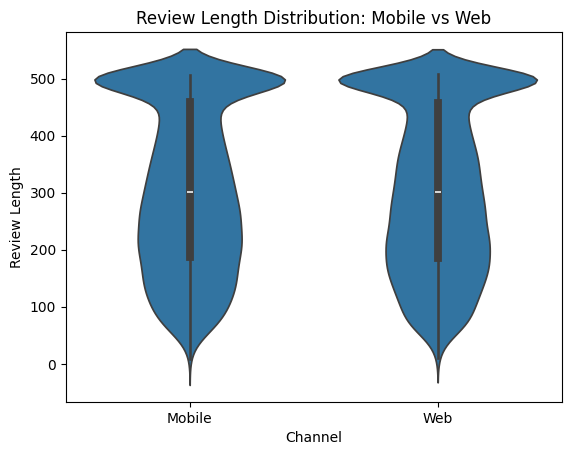

In [5]:
plt.figure()

sns.violinplot(
    data=df_clean,
    x='Channel',
    y='Review Length'
)

plt.title('Review Length Distribution: Mobile vs Web')
plt.xlabel('Channel')
plt.ylabel('Review Length')
plt.show()

In [13]:
#T-Test
mobile_users = df_clean[df_clean['Channel']=='Mobile']
mobile_mean = mobile_users['Review Length'].mean()

web_users = df_clean[df_clean['Channel']=='Web']
web_mean = web_users['Review Length'].mean()
web_sd = web_users['Review Length'].std()
n = web_users['Review Length'].shape[0]

test_statistic = (web_mean-mobile_mean)/ (web_sd/(n**.5))

alpha = .05
critical_value = scipy.stats.t.ppf(1-alpha/2, n-1)
reject_null = abs(test_statistic) > critical_value
print(reject_null)

-0.5363869120270773
1.9601451595523012
